# XGBoost

In [6]:
from xgboost import XGBRegressor
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

In [32]:
df_model = pd.read_csv("/Users/murphy.chen/Desktop/data1030final_project/data/Cleaned/cleaned_car_data.csv")

# define features and target variable
y = df_model["price"]
X = df_model.drop(columns=["price"])

# First split: 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Second split: from remaining 80%, create 60/20
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

# feature list
numeric_features = ["mileage", "engine_size", "seat_num", "door_num", "car_age"]
categorical_features = [
    "gearbox",
    "fuel_type_clean",
    "bodytype_clean",
    "color_clean",
    "brand_model"
]

# pipelines for numeric and categorical features
cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy = "constant", fill_value="Unknown")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", cat_pipeline, categorical_features),
    ],
    remainder="drop"
)

Train: (320532, 10)
Validation: (106844, 10)
Test: (106844, 10)


In [33]:
# Baseline XGBoost model
xgb_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

# fit on train, validate on validation set
xgb_pipeline.fit(X_train, y_train)

y_val_pred = xgb_pipeline.predict(X_val)

mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

print("=== Baseline XGBoost (Validation) ===")
print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:.4f}")

=== Baseline XGBoost (Validation) ===
MAE:  2,359.66
RMSE: 9,528.38
R²:   0.8763


In [34]:
# hypterparameter tuning with GridSearchCV
param_grid = {
    "model__learning_rate": [0.03],
    "model__n_estimators": [8000, 10000],
    "model__max_depth": [6, 8], 
    "model__min_child_weight": [3],
    "model__subsample": [0.7, 0.8],
    "model__colsample_bytree": [0.8, 1.0],
    "model__reg_alpha": [0, 0.1],
    "model__reg_lambda": [1, 5],
    "model__missing": [np.nan],
}

# define the base model
xgb_base = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

# define the pipeline
tune_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", xgb_base)
])

# define the gridsearchCV
xgb_search = GridSearchCV(
    estimator=tune_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=3,
    n_jobs=-1
)

# fit the grid searchCV
xgb_search.fit(X_train, y_train)

print("Best params:")
print(xgb_search.best_params_)

print("\nBest CV MAE:", -xgb_search.best_score_)

Fitting 3 folds for each of 64 candidates, totalling 192 fits
[CV 2/3] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=6, model__min_child_weight=3, model__missing=nan, model__n_estimators=8000, model__reg_alpha=0, model__reg_lambda=5, model__subsample=0.7;, score=-1999.926 total time= 3.0min
[CV 2/3] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=6, model__min_child_weight=3, model__missing=nan, model__n_estimators=8000, model__reg_alpha=0, model__reg_lambda=1, model__subsample=0.7;, score=-1910.742 total time= 3.0min
[CV 1/3] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=6, model__min_child_weight=3, model__missing=nan, model__n_estimators=8000, model__reg_alpha=0, model__reg_lambda=1, model__subsample=0.7;, score=-1771.332 total time= 3.1min
[CV 2/3] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=6, model__min_child_weight=3, model__missing=nan, model__n_estimators

/opt/anaconda3/envs/data1030/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV 3/3] END model__colsample_bytree=1.0, model__learning_rate=0.03, model__max_depth=8, model__min_child_weight=3, model__missing=nan, model__n_estimators=10000, model__reg_alpha=0, model__reg_lambda=5, model__subsample=0.8;, score=-1574.271 total time= 7.2min
[CV 1/3] END model__colsample_bytree=1.0, model__learning_rate=0.03, model__max_depth=8, model__min_child_weight=3, model__missing=nan, model__n_estimators=10000, model__reg_alpha=0.1, model__reg_lambda=1, model__subsample=0.7;, score=-1480.502 total time= 6.3min
[CV 2/3] END model__colsample_bytree=1.0, model__learning_rate=0.03, model__max_depth=8, model__min_child_weight=3, model__missing=nan, model__n_estimators=10000, model__reg_alpha=0.1, model__reg_lambda=1, model__subsample=0.7;, score=-1619.905 total time= 6.1min
[CV 2/3] END model__colsample_bytree=1.0, model__learning_rate=0.03, model__max_depth=8, model__min_child_weight=3, model__missing=nan, model__n_estimators=10000, model__reg_alpha=0.1, model__reg_lambda=1, mode

In [36]:
# get the best pipeline
best_model = xgb_search.best_estimator_

# fit on train and val
best_model.fit(X_train_val, y_train_val)

# evaluate on test set
y_test_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)

print("\n=== Final Tuned XGBoost (Test Set) ===")
print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:.4f}")


=== Final Tuned XGBoost (Test Set) ===
MAE:  1,239.82
RMSE: 2,714.37
R²:   0.9863


In [38]:
# best index in the grid search for XGBoost
best_idx = xgb_search.best_index_

cv_mae_mean = -xgb_search.cv_results_["mean_test_score"][best_idx]
cv_mae_std = xgb_search.cv_results_["std_test_score"][best_idx]

print("=== XGBoost Cross-Validation MAE ===")
print(f"Mean MAE: {cv_mae_mean:,.2f}")
print(f"Std MAE:  {cv_mae_std:,.2f}")

=== XGBoost Cross-Validation MAE ===
Mean MAE: 1,513.42
Std MAE:  51.24


# Elastic Net

In [8]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)



In [9]:
# define features and target variable
y = df_model["price"]
X = df_model.drop(columns=["price"])

# feature lists
numeric_features = ["mileage", "engine_size", "seat_num", "door_num", "car_age"]
categorical_features = [
    "gearbox",
    "fuel_type_clean",
    "bodytype_clean",
    "color_clean",
    "brand_model"
]

# build numeric and categorical transformers
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            IterativeImputer(
                estimator=RandomForestRegressor(
                    n_estimators=1,
                    random_state=42
                ),
                random_state=42,
                max_iter=20,
                tol =1e-2
            )
        ),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# column transformer
preprocessor_enet = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# elastic net pipeline
enet_model = ElasticNet(max_iter=20000, random_state=42)

enet_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_enet),
        ("model", enet_model)
    ]
)

In [10]:
# baseline, always predict the mean of y_train_val
baseline_pred = np.full_like(y_test, y_train_val.mean())

baseline_mae  = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2   = r2_score(y_test, baseline_pred)

print("\n=== Baseline (Mean Predictor) ===")
print(f"MAE:  {baseline_mae:,.2f}")
print(f"RMSE: {baseline_rmse:,.2f}")
print(f"R²:   {baseline_r2:.4f}")


=== Baseline (Mean Predictor) ===
MAE:  10,972.35
RMSE: 23,208.60
R²:   -0.0000


In [14]:
# hyperparameter tuning for ElasticNet
from sklearn.model_selection import RandomizedSearchCV

param_grid_enet = {
    "model__alpha": [0.01, 0.05, 0.1, 0.3, 1, 3, 10],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}


# grid search CV for ElasticNet
enet_search = GridSearchCV(
    estimator=enet_pipeline,
    param_grid=param_grid_enet,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1,
    verbose=2
)

# fit the grid search CV on train data
enet_search.fit(X_train, y_train)

print("Best Elastic Net params:")
print(enet_search.best_params_)

print("\nBest CV MAE:", -enet_search.best_score_)

Fitting 3 folds for each of 35 candidates, totalling 105 fits
[CV] END .............model__alpha=0.01, model__l1_ratio=0.1; total time=  44.5s
[CV] END .............model__alpha=0.01, model__l1_ratio=0.1; total time=  55.0s
[CV] END .............model__alpha=0.01, model__l1_ratio=0.3; total time=  58.3s
[CV] END .............model__alpha=0.01, model__l1_ratio=0.3; total time= 1.1min
[CV] END .............model__alpha=0.01, model__l1_ratio=0.1; total time= 1.1min
[CV] END .............model__alpha=0.01, model__l1_ratio=0.3; total time= 1.3min
[CV] END .............model__alpha=0.05, model__l1_ratio=0.1; total time=  14.5s
[CV] END .............model__alpha=0.05, model__l1_ratio=0.1; total time=  18.6s
[CV] END .............model__alpha=0.05, model__l1_ratio=0.3; total time=  15.2s
[CV] END .............model__alpha=0.05, model__l1_ratio=0.1; total time=  18.1s
[CV] END .............model__alpha=0.01, model__l1_ratio=0.5; total time= 1.6min
[CV] END .............model__alpha=0.01, model_

/opt/anaconda3/envs/data1030/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END .............model__alpha=0.05, model__l1_ratio=0.5; total time=  20.2s
[CV] END .............model__alpha=0.05, model__l1_ratio=0.7; total time=  26.9s
[CV] END .............model__alpha=0.01, model__l1_ratio=0.7; total time= 2.1min
[CV] END .............model__alpha=0.05, model__l1_ratio=0.7; total time=  28.9s
[CV] END ..............model__alpha=0.1, model__l1_ratio=0.1; total time=  10.7s
[CV] END .............model__alpha=0.05, model__l1_ratio=0.7; total time=  28.4s
[CV] END .............model__alpha=0.01, model__l1_ratio=0.7; total time= 2.4min
[CV] END ..............model__alpha=0.1, model__l1_ratio=0.1; total time=  13.6s
[CV] END .............model__alpha=0.01, model__l1_ratio=0.7; total time= 2.4min
[CV] END ..............model__alpha=0.1, model__l1_ratio=0.3; total time=  11.4s
[CV] END ..............model__alpha=0.1, model__l1_ratio=0.1; total time=  12.0s
[CV] END ..............model__alpha=0.1, model__l1_ratio=0.3; total time=  14.7s
[CV] END ..............model

In [15]:
# get the best pipeline
best_enet_pipeline = enet_search.best_estimator_


# refit on train and val
best_enet_pipeline.fit(X_train_val, y_train_val)

y_test_pred_enet = best_enet_pipeline.predict(X_test)

enet_mae = mean_absolute_error(y_test, y_test_pred_enet)
enet_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_enet))
enet_r2 = r2_score(y_test, y_test_pred_enet)

print("\n=== Final Tuned ElasticNet (Test Set) ===")
print(f"MAE:  {enet_mae:,.2f}")
print(f"RMSE: {enet_rmse:,.2f}")
print(f"R²:   {enet_r2:.4f}")


=== Final Tuned ElasticNet (Test Set) ===
MAE:  5,896.75
RMSE: 15,912.27
R²:   0.5299


In [19]:
# 1. Get the index of the best performing hyperparameter combination
best_enet_idx = enet_search.best_index_

# 2. Extract the mean and standard deviation of the CV score (MAE) at this index
# The score is 'neg_mean_absolute_error', so we negate it to get MAE
cv_enet_mae_mean = -enet_search.cv_results_["mean_test_score"][best_enet_idx]
cv_enet_mae_std = enet_search.cv_results_["std_test_score"][best_enet_idx]

# 3. Print the results
print("\n=== Elastic Net Cross-Validation MAE ===")
print(f"Mean MAE: {cv_enet_mae_mean:,.2f}")
print(f"Std MAE:  {cv_enet_mae_std:,.2f}")


=== Elastic Net Cross-Validation MAE ===
Mean MAE: 6,045.76
Std MAE:  8.98


# Random Forest

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# feature lists (same as for XGBoost)
numeric_features = ["mileage", "engine_size", "seat_num", "door_num", "car_age"]
categorical_features = [
    "gearbox",
    "fuel_type_clean",
    "bodytype_clean",
    "color_clean",
    "brand_model"
]

# numeric: median imputation for RF (must have no NaNs)
num_pipeline_rf = Pipeline(
    steps=[
        (
            "imputer",
            IterativeImputer(
                estimator=RandomForestRegressor(
                    n_estimators=1,
                    random_state=42
                ),
                random_state=42,
                max_iter=20,
                tol =1e-2
            )
        ),
        ("scaler", StandardScaler())
    ]
)

# categorical: impute "Unknown" then OHE
cat_pipeline_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline_rf, numeric_features),
        ("cat", cat_pipeline_rf, categorical_features),
    ],
    remainder="drop"
)


In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# baseline RF
rf_base = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,          # let it grow fully initially
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rf_pipeline = Pipeline(steps=[
    ("preprocessor", rf_preprocessor),
    ("model", rf_base)
])

# fit on TRAIN
rf_pipeline.fit(X_train, y_train)

# validate on VAL
y_val_pred_rf = rf_pipeline.predict(X_val)

rf_mae = mean_absolute_error(y_val, y_val_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
rf_r2 = r2_score(y_val, y_val_pred_rf)

print("=== Baseline Random Forest (Validation) ===")
print(f"MAE:  {rf_mae:,.2f}")
print(f"RMSE: {rf_rmse:,.2f}")
print(f"R²:   {rf_r2:.4f}")


=== Baseline Random Forest (Validation) ===
MAE:  1,036.34
RMSE: 7,919.45
R²:   0.9145


In [24]:
from sklearn.model_selection import RandomizedSearchCV

rf_tune = RandomForestRegressor(
    n_estimators=300,
    n_jobs=-1,
    random_state=42
)

rf_tune_pipeline = Pipeline(steps=[
    ("preprocessor", rf_preprocessor),
    ("model", rf_tune)
])

rf_param_dist = {
    "model__n_estimators": [200, 300, 400],
    "model__max_depth": [None, 10, 20, 40],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.3],
}

rf_search = RandomizedSearchCV(
    estimator=rf_tune_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,                         # reasonable budget
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

rf_search.fit(X_train, y_train)

print("\nBest RF params:")
print(rf_search.best_params_)
print("Best CV MAE:", -rf_search.best_score_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=4, model__min_samples_split=10, model__n_estimators=200; total time=   8.8s
[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200; total time=   9.1s
[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=4, model__min_samples_split=10, model__n_estimators=200; total time=  15.0s
[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200; total time=  16.3s
[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=4, model__min_samples_split=10, model__n_estimators=200; total time=  26.3s
[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200; total time=  28.9s
[CV] E

/opt/anaconda3/envs/data1030/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=300; total time= 1.1min
[CV] END model__max_depth=20, model__max_features=0.3, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=200; total time= 6.1min
[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=300; total time= 1.4min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=4, model__min_samples_split=10, model__n_estimators=200; total time= 1.0min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=400; total time= 3.1min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=4, model__min_samples_split=10, model__n_estimators=200; total time= 1.4min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_

In [25]:
# best pipeline (includes preprocessing + RF)
best_rf_pipeline = rf_search.best_estimator_

# retrain on TRAIN+VAL (80%)
best_rf_pipeline.fit(X_train_val, y_train_val)

# evaluate on TEST
y_test_pred_rf = best_rf_pipeline.predict(X_test)

rf_test_mae = mean_absolute_error(y_test, y_test_pred_rf)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
rf_test_r2 = r2_score(y_test, y_test_pred_rf)

print("\n=== Tuned Random Forest (Test Set) ===")
print(f"MAE:  {rf_test_mae:,.2f}")
print(f"RMSE: {rf_test_rmse:,.2f}")
print(f"R²:   {rf_test_r2:.4f}")



=== Tuned Random Forest (Test Set) ===
MAE:  1,029.52
RMSE: 5,325.80
R²:   0.9473


# KNN

In [26]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", IterativeImputer(
            estimator=RandomForestRegressor(n_estimators=1, random_state=42),
            max_iter=20,
            tol=1e-2,
            random_state=42
        )),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ]
)


from sklearn.compose import ColumnTransformer

preprocessor_knn = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Baseline KNN model
knn_base = KNeighborsRegressor(
    n_neighbors=5,
    weights="distance",  # closer neighbors contribute more
    p=2,                 # Euclidean distance
    n_jobs=-1
)

knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_knn),
    ("model", knn_base)
])

# Fit on TRAIN
knn_pipeline.fit(X_train, y_train)

# Validate on VAL
y_val_pred_knn = knn_pipeline.predict(X_val)

knn_mae = mean_absolute_error(y_val, y_val_pred_knn)
knn_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_knn))
knn_r2 = r2_score(y_val, y_val_pred_knn)

print("=== Baseline KNN (Validation) ===")
print(f"MAE:  {knn_mae:,.2f}")
print(f"RMSE: {knn_rmse:,.2f}")
print(f"R²:   {knn_r2:.4f}")


=== Baseline KNN (Validation) ===
MAE:  739.89
RMSE: 4,495.17
R²:   0.9725


In [28]:
from sklearn.model_selection import GridSearchCV

knn_tune = KNeighborsRegressor(
    n_jobs=-1
)

knn_tune_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_knn),
    ("model", knn_tune)
])

param_grid_knn = {
    "model__n_neighbors": [10, 20],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],   # Manhattan vs Euclidean
}

knn_search = GridSearchCV(
    estimator=knn_tune_pipeline,
    param_grid=param_grid_knn,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1,
    verbose=2
)

knn_search.fit(X_train, y_train)

print("\nBest KNN params:")
print(knn_search.best_params_)
print("Best CV MAE:", -knn_search.best_score_)


Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END model__n_neighbors=10, model__p=2, model__weights=distance; total time=14.0min
[CV] END model__n_neighbors=10, model__p=2, model__weights=uniform; total time=14.2min
[CV] END model__n_neighbors=10, model__p=2, model__weights=distance; total time=14.3min
[CV] END model__n_neighbors=10, model__p=2, model__weights=uniform; total time=14.4min
[CV] END model__n_neighbors=10, model__p=2, model__weights=uniform; total time=14.5min
[CV] END model__n_neighbors=10, model__p=2, model__weights=distance; total time=14.6min
[CV] END model__n_neighbors=10, model__p=1, model__weights=distance; total time=19.1min
[CV] END model__n_neighbors=10, model__p=1, model__weights=uniform; total time=19.1min
[CV] END model__n_neighbors=10, model__p=1, model__weights=distance; total time=19.1min
[CV] END model__n_neighbors=10, model__p=1, model__weights=uniform; total time=19.2min
[CV] END model__n_neighbors=10, model__p=1, model__weights=distan

In [29]:
# Best tuned KNN pipeline
best_knn_pipeline = knn_search.best_estimator_

# Retrain on TRAIN+VAL
best_knn_pipeline.fit(X_train_val, y_train_val)

# Test evaluation
y_test_pred_knn = best_knn_pipeline.predict(X_test)

knn_test_mae = mean_absolute_error(y_test, y_test_pred_knn)
knn_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_knn))
knn_test_r2 = r2_score(y_test, y_test_pred_knn)

print("\n=== Tuned KNN (Test Set) ===")
print(f"MAE:  {knn_test_mae:,.2f}")
print(f"RMSE: {knn_test_rmse:,.2f}")
print(f"R²:   {knn_test_r2:.4f}")



=== Tuned KNN (Test Set) ===
MAE:  381.53
RMSE: 2,496.02
R²:   0.9884


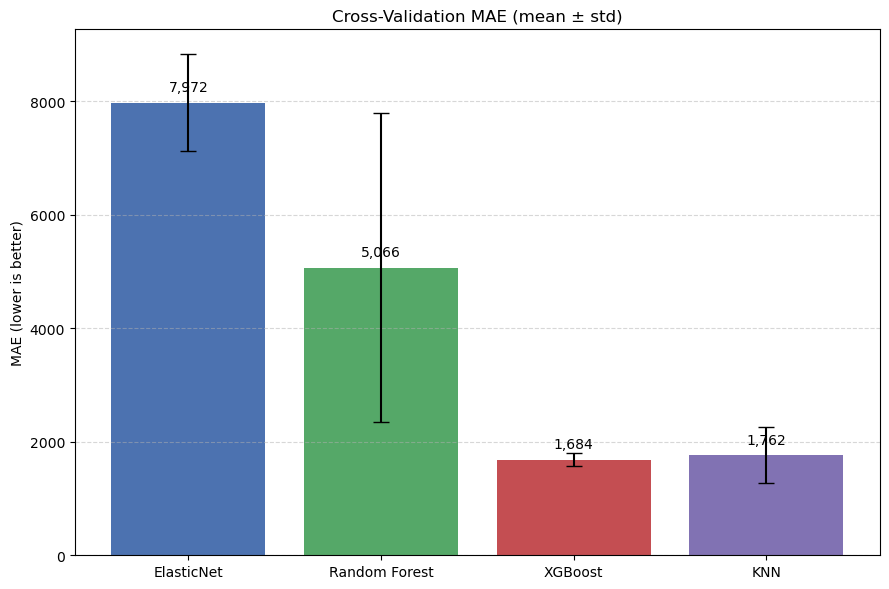

In [40]:
model_results = {
    "ElasticNet": enet_search.cv_results_["mean_test_score"],
    "Random Forest": rf_search.cv_results_["mean_test_score"],
    "XGBoost": xgb_search.cv_results_["mean_test_score"],
    "KNN": knn_search.cv_results_["mean_test_score"]
}


import numpy as np

models = ["ElasticNet", "Random Forest", "XGBoost", "KNN"]

mean_mae = [
    -np.mean(enet_search.cv_results_["mean_test_score"]),
    -np.mean(rf_search.cv_results_["mean_test_score"]),
    -np.mean(xgb_search.cv_results_["mean_test_score"]),
    -np.mean(knn_search.cv_results_["mean_test_score"]),
]

std_mae = [
    np.std(enet_search.cv_results_["mean_test_score"]),
    np.std(rf_search.cv_results_["mean_test_score"]),
    np.std(xgb_search.cv_results_["mean_test_score"]),
    np.std(knn_search.cv_results_["mean_test_score"]),
]

import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))
plt.bar(models, mean_mae, yerr=std_mae, capsize=6, color=["#4C72B0","#55A868","#C44E52","#8172B3"])

plt.ylabel("MAE (lower is better)")
plt.title("Cross-Validation MAE (mean ± std)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

for i, v in enumerate(mean_mae):
    plt.text(i, v + 200, f"{v:,.0f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()


In [42]:
from sklearn.inspection import permutation_importance

# Use your tuned XGBoost pipeline as the estimator
estimator =  best_model # you can swap to best_enet_pipeline, best_rf_pipeline, etc.

result = permutation_importance(
    estimator,
    X_val,
    y_val,
    n_repeats=5,
    random_state=42,
    scoring="neg_mean_absolute_error"  # same metric as your CV
)

# Build a nice DataFrame of global feature importances
feature_names = X_val.columns  # original features: mileage, engine_size, ..., brand_model

perm_importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

perm_importance_df.head(15)

top_k = 15
top_imp = perm_importance_df.head(top_k)

plt.figure(figsize=(8, 6))
plt.barh(top_imp["feature"], top_imp["importance_mean"], xerr=top_imp["importance_std"])
plt.gca().invert_yaxis()

plt.xlabel("Permutation Importance (Δ score)")
plt.title("Global Feature Importance via Permutation (XGBoost, MAE)")
plt.tight_layout()
plt.show()



KeyboardInterrupt: 

940 features after preprocessing


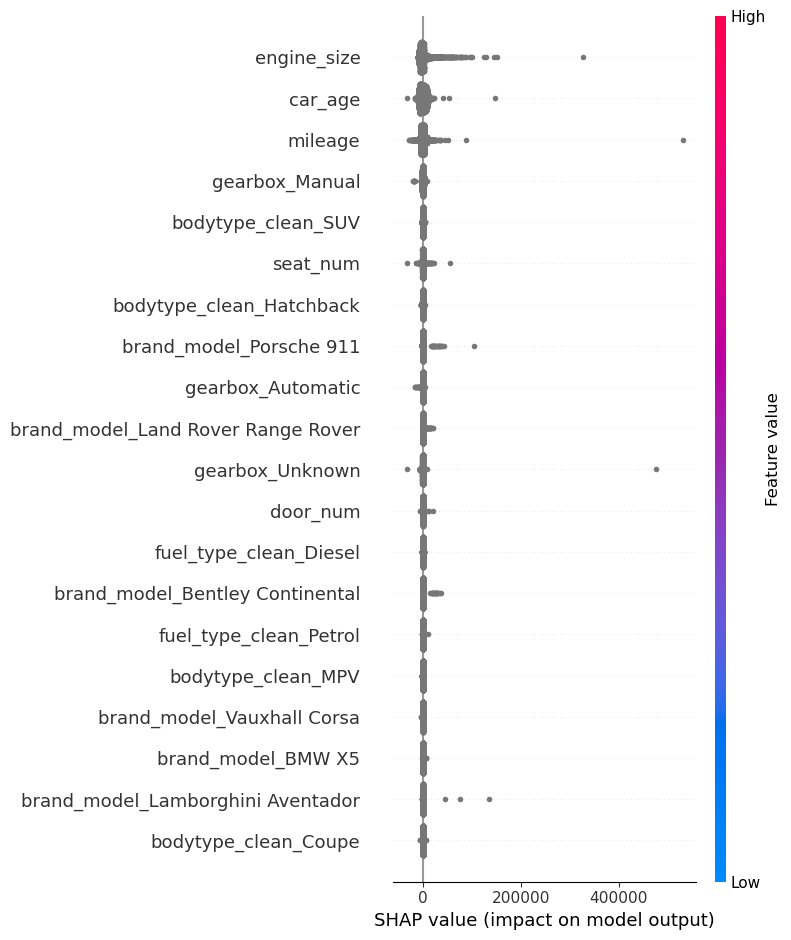

In [47]:
import numpy as np
import pandas as pd

# 1. Grab pieces from your fitted pipeline
preprocessor = best_model.named_steps["preprocessor"]
xgb_model    = best_model.named_steps["model"]

# 2. Take a smaller sample of validation data for SHAP (e.g., 5,000 rows)
X_val_sample = X_val.sample(n=5000, random_state=42)
y_val_sample = y_val.loc[X_val_sample.index]

# 3. Transform with the preprocessor
X_val_trans = preprocessor.transform(X_val_sample)

# Get feature names after preprocessing
feature_names = []

for name, transformer, cols in preprocessor.transformers_:
    if name == "num":
        # numeric passthrough → same column names
        feature_names.extend(cols)
    elif name == "cat":
        # cat pipeline: we need the OneHotEncoder inside
        ohe = transformer.named_steps["ohe"]
        # cols here are the original categorical column names
        ohe_feature_names = ohe.get_feature_names_out(cols)
        feature_names.extend(ohe_feature_names)

feature_names = np.array(feature_names)
print(len(feature_names), "features after preprocessing")



import shap

# Use a small sample of TRAIN data as background for SHAP
X_train_bg = X_train.sample(n=5000, random_state=42)
X_train_bg_trans = preprocessor.transform(X_train_bg)

# TreeExplainer works well for XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values on transformed validation sample
# (check_additivity=False avoids some warnings for XGBoost)
shap_values = explainer.shap_values(X_val_trans, check_additivity=False)


import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_val_trans,
    feature_names=feature_names,
    show=False
)
plt.tight_layout()
plt.show()


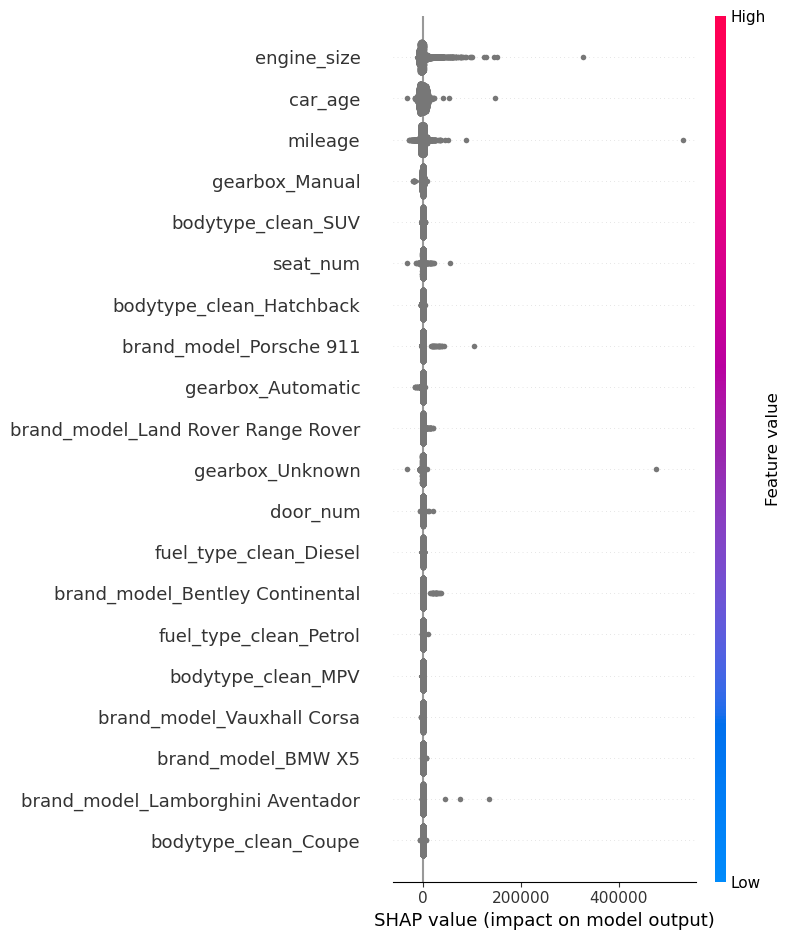

In [48]:
import shap
import numpy as np

# Compute mean(|SHAP|) for each feature
shap_importance = np.abs(shap_values).mean(axis=0)

# Sort indices
sorted_idx = np.argsort(shap_importance)

# Summary plot with sorted features
shap.summary_plot(
    shap_values[:, sorted_idx],
    X_val_trans[:, sorted_idx],
    feature_names=feature_names[sorted_idx],
    show=False
)
plt.tight_layout()
plt.show()


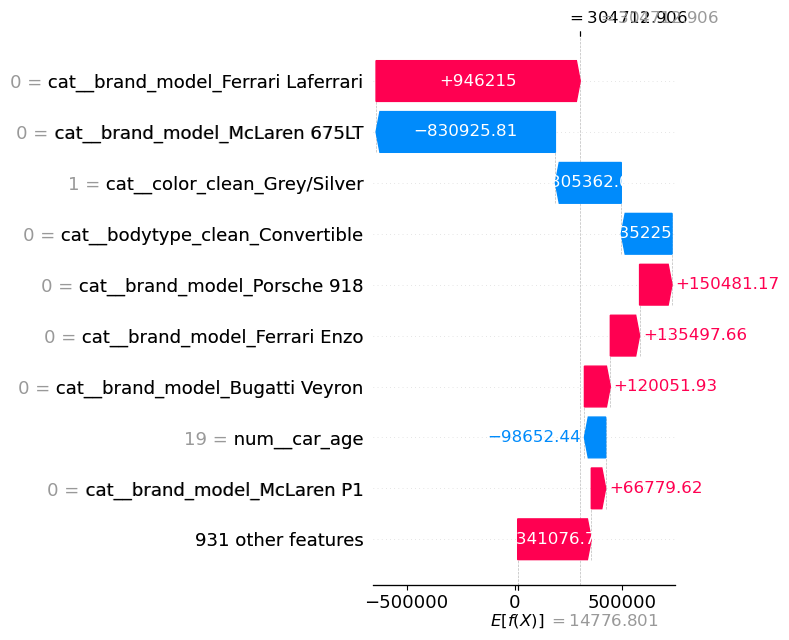

In [52]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# 1. Transform validation data with the preprocessor
X_val_trans = best_model.named_steps["preprocessor"].transform(X_val)

# Convert to dense (required for SHAP waterfall)
X_val_trans_dense = X_val_trans.toarray()

# 2. Get feature names from the preprocessor
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# 3. (Optional) sample some rows for SHAP to keep it fast
n_sample = 200
rng = np.random.default_rng(42)
idx = rng.choice(X_val_trans_dense.shape[0], size=n_sample, replace=False)

X_shap = X_val_trans_dense[idx]

# 4. Build the explainer on the XGBoost model only
xgb_model = best_model.named_steps["model"]
explainer = shap.TreeExplainer(xgb_model)

# 5. Compute SHAP values for the sampled rows
shap_values = explainer.shap_values(X_shap)   # shape: (n_sample, n_features)

# 6. Pick one row for a local explanation
i = 0  # index *within* the sampled matrix X_shap

exp = shap.Explanation(
    values=shap_values[i],
    base_values=explainer.expected_value,
    data=X_shap[i],
    feature_names=feature_names,
)

shap.plots.waterfall(exp, show=False)
plt.tight_layout()
plt.show()


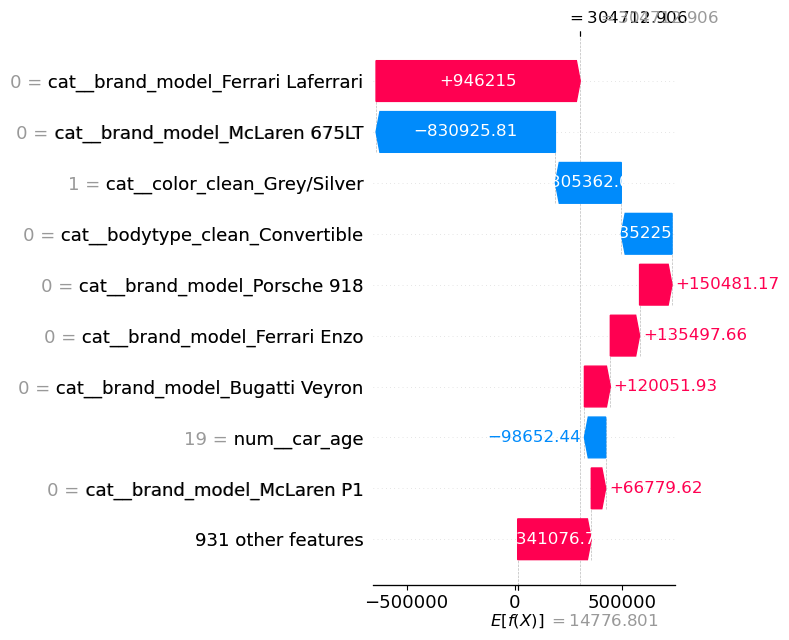

In [53]:
i = 0  # keep whichever row you want from X_shap

exp = shap.Explanation(
    values=shap_values[i],
    base_values=explainer.expected_value,
    data=X_shap[i],
    feature_names=feature_names,
)

shap.plots.waterfall(exp, max_display=10, show=False)
plt.tight_layout()
plt.show()


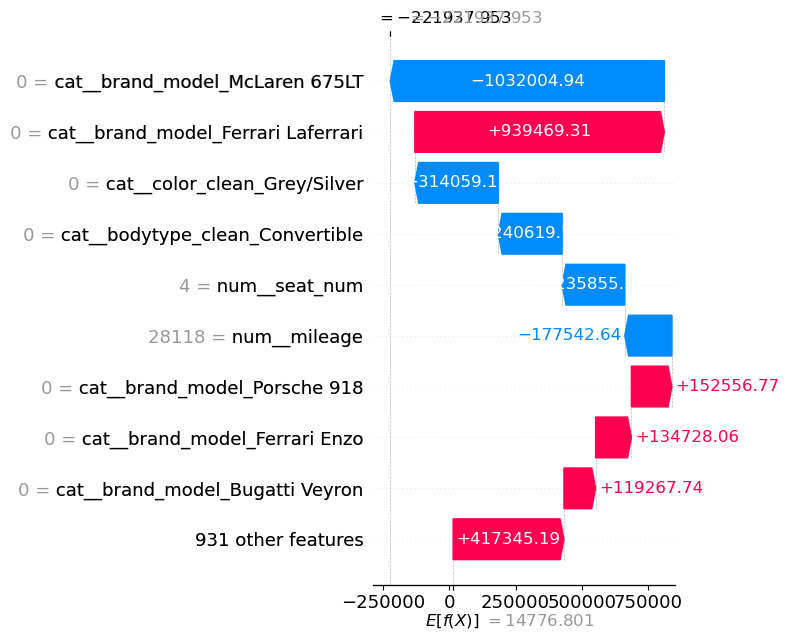

In [55]:
# 1. Get predictions on full validation set
y_val_pred_full = best_model.predict(X_val)

# 2. Find index of car whose predicted price is closest to the median
median_pred = np.median(y_val_pred_full)
i_global = np.argmin(np.abs(y_val_pred_full - median_pred))

# 3. Transform that single row and compute SHAP values just for it
X_one = best_model.named_steps["preprocessor"].transform(
    X_val.iloc[[i_global]]
).toarray()

explainer = shap.TreeExplainer(best_model.named_steps["model"])
shap_values_one = explainer.shap_values(X_one)

exp = shap.Explanation(
    values=shap_values_one[0],
    base_values=explainer.expected_value,
    data=X_one[0],
    feature_names=feature_names,
)

shap.plots.waterfall(exp, max_display=10, show=False)
plt.tight_layout()
plt.show()
